# C1.3 — The Central Difference Method

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.1 — Motivation

The Forward Euler method uses information only from the current point:

$$
y_{n+1}=y_n+h f(t_n,y_n).
$$

Although simple, this introduces an asymmetry in time because the derivative is approximated using information only from one side of the point.

A more balanced approach is to use information from both sides of a point.

This leads to the **central difference approximation**.

The central difference method is important because it:

- improves derivative accuracy,
- treats past and future more symmetrically,
- appears naturally in many physics problems,
- forms the basis of many finite-difference methods,
- is widely used in wave equations and mechanics simulations.

The central difference approximation is especially valuable in physics because many physical laws are naturally time-symmetric.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.2 — Deriving the Central Difference Approximation

Consider a function $y(t)$.

We approximate the derivative at time $t_n$ using the neighboring points:

$$
(t_{n-1},y_{n-1})
\quad \text{and} \quad
(t_{n+1},y_{n+1}).
$$

The slope between these points is

$$
\frac{y_{n+1}-y_{n-1}}{2h}.
$$

This gives the **central difference approximation**:

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Central Difference Approximation</strong>

$$
\left.\frac{dy}{dt}\right|_{t_n}
\approx
\frac{y_{n+1}-y_{n-1}}{2h}.
$$

This approximation uses information from both sides of the point.
</div>

Compared to Forward Euler,

$$
\frac{y_{n+1}-y_n}{h},
$$

the central difference method is more symmetric.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.3 — Accuracy of the Central Difference Method

The Forward Euler derivative approximation has truncation error proportional to

$$
h.
$$

The central difference approximation has truncation error proportional to

$$
h^2.
$$

This means the central difference method is generally much more accurate for the same step size.

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Order of Accuracy</strong>

Forward difference:

$$
\frac{y_{n+1}-y_n}{h}
\quad \rightarrow \quad
\mathcal{O}(h)
$$

Central difference:

$$
\frac{y_{n+1}-y_{n-1}}{2h}
\quad \rightarrow \quad
\mathcal{O}(h^2)
$$

The central difference approximation is second-order accurate.
</div>

Reducing the step size improves both methods, but the central difference method converges faster.

<div style="background-color:#e8f5e9; border-left:6px solid #006633; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Box Activity — Proving the Accuracy Using Taylor Expansions</h3>

Use Taylor expansions about the point $t_n$ to show that the central difference approximation

$$
\frac{y_{n+1}-y_{n-1}}{2h}
$$

has truncation error of order

$$
\mathcal{O}(h^2).
$$

Hint:

Expand both

$$
y(t_n+h)
\quad \text{and} \quad
y(t_n-h)
$$

about $t_n$.

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Activity solution
</summary>

Expand $y(t_n+h)$ about $t_n$:

$$
y_{n+1}
=
y_n
+
h y_n'
+
\frac{h^2}{2}y_n''
+
\frac{h^3}{6}y_n'''
+
\mathcal{O}(h^4).
$$

Now expand $y(t_n-h)$:

$$
y_{n-1}
=
y_n
-
h y_n'
+
\frac{h^2}{2}y_n''
-
\frac{h^3}{6}y_n'''
+
\mathcal{O}(h^4).
$$

Subtract the two expressions:

$$
y_{n+1}-y_{n-1}
=
2h y_n'
+
\frac{2h^3}{6}y_n'''
+
\mathcal{O}(h^5).
$$

Simplify:

$$
y_{n+1}-y_{n-1}
=
2h y_n'
+
\frac{h^3}{3}y_n'''
+
\mathcal{O}(h^5).
$$

Now divide by $2h$:

$$
\frac{y_{n+1}-y_{n-1}}{2h}
=
y_n'
+
\frac{h^2}{6}y_n'''
+
\mathcal{O}(h^4).
$$

Therefore,

$$
\frac{y_{n+1}-y_{n-1}}{2h}
=
\left.\frac{dy}{dt}\right|_{t_n}
+
\mathcal{O}(h^2).
$$

The leading truncation error is proportional to $h^2$, so the central difference approximation is second-order accurate.

</details>
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.4 — Central Difference Form of a Differential Equation

Suppose we have

$$
\frac{dy}{dt}=f(t,y).
$$

Using the central difference approximation,

$$
\frac{y_{n+1}-y_{n-1}}{2h}
=
f(t_n,y_n).
$$

Solving for $y_{n+1}$ gives

$$
y_{n+1}=y_{n-1}+2h f(t_n,y_n).
$$

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Central Difference Update Equation</strong>

$$
y_{n+1}=y_{n-1}+2h f(t_n,y_n).
$$

Unlike Forward Euler, this method requires two previous points.
</div>

Because the method uses both past and future neighboring points, it behaves differently from one-step methods like Euler.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.5 — Why Two Initial Values Are Needed

Forward Euler requires only one starting value:

$$
y_0.
$$

The central difference method requires

$$
y_{n-1}
\quad \text{and} \quad
y_n.
$$

Therefore, we must somehow obtain two starting values before the method can proceed.

Typically this is done by:

- using Forward Euler for the first step,
- using an exact initial derivative,
- using another numerical method to generate the second point.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">
<strong>Danger:</strong><br>

The central difference method is not self-starting because the update equation depends on two previous values.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.6 — Example: Exponential Growth

Consider

$$
\frac{dy}{dt}=y,
$$

with initial condition

$$
y(0)=1.
$$

Using the central difference method,

$$
y_{n+1}=y_{n-1}+2h y_n.
$$

Suppose

$$
h=0.1.
$$

To begin, we need two starting values.

We already know

$$
y_0=1.
$$

Use Forward Euler for the first step:

$$
y_1=y_0+h y_0.
$$

Thus,

$$
y_1=1+0.1=1.1.
$$

Now apply the central difference update:

$$
y_2=y_0+2(0.1)y_1.
$$

Therefore,

$$
y_2=1+0.22=1.22.
$$

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Starting the Central Difference Method</h3>

The central difference method requires two initial values.

A common strategy is:

1. use the given initial condition for $y_0$,
2. generate $y_1$ using Forward Euler,
3. continue using the central difference update equation.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.7 — Time Symmetry

One reason the central difference method is important in physics is its symmetry in time.

The derivative approximation uses points equally spaced around the current point:

$$
\frac{y_{n+1}-y_{n-1}}{2h}.
$$

This means the method treats forward and backward directions more equally than Forward Euler.

This symmetry is especially important in:

- classical mechanics,
- wave equations,
- oscillatory systems,
- molecular dynamics,
- conservative systems.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Physical Insight</strong>

Many physical systems do not inherently prefer a forward direction in time. Central difference methods better reflect this symmetry than Forward Euler methods.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.8 — Central Difference for Second Derivatives

The central difference method is especially useful for second derivatives.

Using Taylor expansions, we obtain

$$
\left.\frac{d^2 y}{dt^2}\right|_{t_n}
\approx
\frac{y_{n+1}-2y_n+y_{n-1}}{h^2}.
$$

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Central Difference Approximation for Second Derivatives</strong>

$$
\frac{d^2 y}{dt^2}
\approx
\frac{y_{n+1}-2y_n+y_{n-1}}{h^2}.
$$

This formula is fundamental in numerical physics.
</div>

This approximation appears in:

- Newton's second law,
- oscillations,
- wave equations,
- diffusion equations,
- finite difference simulations.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.9 — Box Activity: Harmonic Oscillator

<div style="background-color:#e8f5e9; border-left:6px solid #006633; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Box Activity — Central Difference for Oscillations</h3>

A simple harmonic oscillator satisfies

$$
\frac{d^2x}{dt^2}=-\omega^2 x.
$$

Using the central difference approximation for the second derivative,

$$
\frac{x_{n+1}-2x_n+x_{n-1}}{h^2},
$$

derive an update equation for $x_{n+1}$.

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Activity solution
</summary>

Substitute the central difference approximation into the differential equation:

$$
\frac{x_{n+1}-2x_n+x_{n-1}}{h^2}
=
-\omega^2 x_n.
$$

Multiply by $h^2$:

$$
x_{n+1}-2x_n+x_{n-1}
=
-\omega^2 h^2 x_n.
$$

Solve for $x_{n+1}$:

$$
x_{n+1}
=
2x_n-x_{n-1}-\omega^2 h^2 x_n.
$$

Therefore,

$$
x_{n+1}
=
(2-\omega^2 h^2)x_n-x_{n-1}.
$$

This update equation is widely used in computational mechanics and wave simulations.

</details>
</div>

---

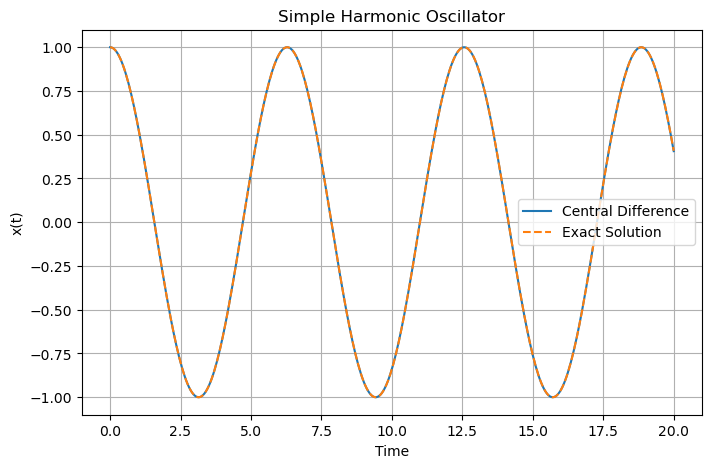

In [2]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Parameters
omega = 1.0
h = 0.05
t_final = 20

# Time array
t = np.arange(0, t_final+h, h)

# Arrays
x = np.zeros(len(t))

# Initial conditions
x[0] = 1.0
v0 = 0.0

# Start using Taylor expansion
x[1] = x[0] + h*v0 - 0.5*(omega**2)*(h**2)*x[0]

# Central difference update
for n in range(1, len(t)-1):
    x[n+1] = (2 - omega**2*h**2)*x[n] - x[n-1]

# Exact solution
x_exact = np.cos(omega*t)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, x, label='Central Difference')
plt.plot(t, x_exact, '--', label='Exact Solution')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Simple Harmonic Oscillator')
plt.grid(True)
plt.legend()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.3.10 — Summary

The central difference approximation is

$$
\frac{y_{n+1}-y_{n-1}}{2h}.
$$

Key ideas:

- it uses information from both sides of a point,
- it is more symmetric than Forward Euler,
- it is second-order accurate,
- it requires two starting values,
- it is especially useful for oscillatory and wave systems,
- it forms the foundation of many finite-difference methods.

The second-derivative approximation

$$
\frac{y_{n+1}-2y_n+y_{n-1}}{h^2}
$$

is one of the most important formulas in computational physics.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Big Picture</strong>

The central difference method introduces one of the most important ideas in computational physics:

$$
\text{local derivatives}
\quad \longrightarrow \quad
\text{algebraic relationships between neighboring grid points}.
$$

This idea underlies finite difference methods for mechanics, electromagnetism, fluid dynamics, and quantum mechanics.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">